In [1]:
import os
from pathlib import Path

def root_dir(marker="EXPLib"):
    cwd = Path.cwd()
    # if cwd already contains the marker
    if (cwd / marker).is_dir():
        return cwd
    # otherwise walk up the parents
    for p in cwd.parents:
        if (p / marker).is_dir():
            return p
    raise FileNotFoundError(f"Root marker '{marker}' not found")

os.chdir(root_dir())
#print(os.getcwd())

In [2]:
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
from EXPLib.xai_library.data_explainers.data_descriptors import vae_descriptor

In [3]:
# Set device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define local dataset folder
dataset_folder = './EXPLib/datasets/Camera/toy_model_v1_inference/dev/images'
saved_model_folder = './EXPLib/dl_component/AEs/VAE/weight'
model_name = 'vae_model20240617_toy_dev_img.pth'

resized_width = 160
resized_height = 160
latent_dim = 256

In [4]:
model_path = os.path.join(saved_model_folder, model_name)

vae_model = vae_descriptor.VAE(input_shape=(3, resized_height, resized_width), latent_dim=latent_dim).to(device)
vae_model = vae_descriptor.load_vae_model(vae_model, model_path, device)


In [5]:
test_img_folder = './EXPLib/datasets/Camera/toy_model_v1_inference/inference'
test_image='rgb_0000079_modified.png'
reconstructed_image, anomaly_score = vae_descriptor.detect_anomaly(vae_model, os.path.join(test_img_folder, test_image))

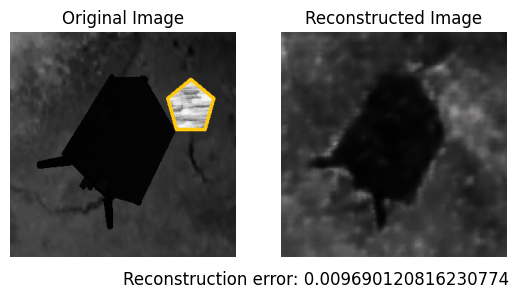

In [6]:
import matplotlib.pyplot as plt

original_image = Image.open(os.path.join(test_img_folder, test_image)).convert("RGB")
# Display the image
plt.figure
plt.subplot(1, 2, 1)
plt.title(f"Original Image")
plt.imshow(original_image)
plt.axis("off")
plt.text(0.5, -0.1, f"Reconstruction error: {anomaly_score}", ha='left', va='center', transform=plt.gca().transAxes, fontsize=12, color='black')


plt.subplot(1, 2, 2)
plt.title(f"Reconstructed Image")
plt.imshow(reconstructed_image.permute(1, 2, 0))
plt.axis("off")

plt.show()

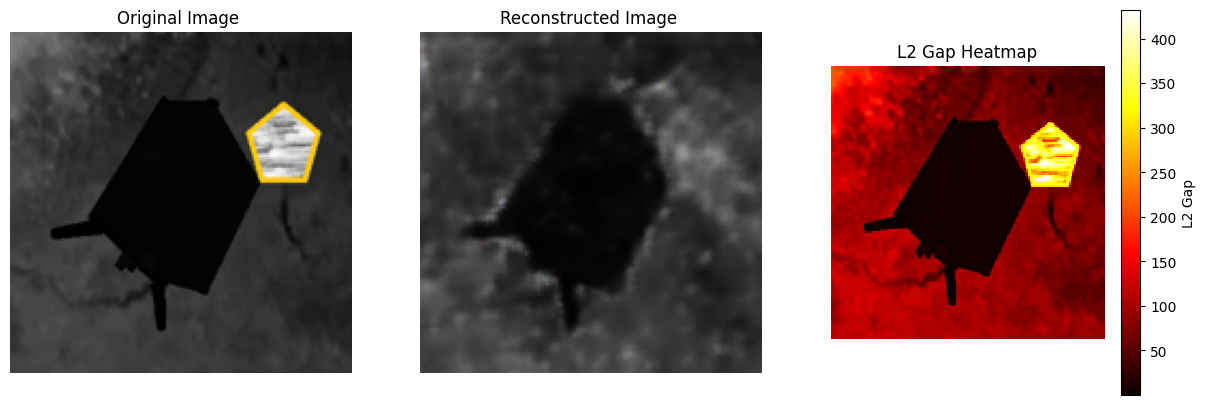

In [7]:
import numpy as np
reconstructed_image_reshaped = reconstructed_image.permute(1, 2, 0).cpu().detach().numpy()

original_image_resized = original_image.resize((reconstructed_image_reshaped.shape[0], reconstructed_image.shape[1]))
original_image_resized = np.array(original_image_resized)

l2_gap = np.sqrt(np.sum((original_image_resized - reconstructed_image_reshaped) ** 2, axis=2))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title(f"Original Image ")
plt.imshow(original_image_resized)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title(f"Reconstructed Image ")
plt.imshow(reconstructed_image_reshaped)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("L2 Gap Heatmap")
plt.imshow(l2_gap, cmap='hot', interpolation='nearest')
plt.colorbar(label='L2 Gap')
plt.axis("off")

plt.show()